# Fare Revenue & Transaction Analysis
Analyses passenger demographics, system revenue, and peak travel demand from ticket boarding data.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)

In [ ]:
["all_ticket_files = glob.glob(r'..\data\\anonymized\\*.csv')\nif not all_ticket_files:\n    raise FileNotFoundError('No ticket files found.')\n\nfile_to_load = all_ticket_files[0]\ndf_tickets = pd.read_csv(file_to_load)\ndf_tickets['transaction_date'] = pd.to_datetime(df_tickets['transaction_date'])\nprint(f'Loaded {len(df_tickets):,} records from {os.path.basename(file_to_load)}')\ndisplay(df_tickets.head(3))"]

Initializing Ticket Data Ingestion...
Loading data from: ..\data\anonymized\2026-03-01.csv...
Successfully loaded 63,379 transaction records.


,transaction_date,fare_type,vehicle_number,company_number,route_detail_id,integration_flag,card_type,debited_amount,view_type,route_name,day_type,day_period,anon_user_id
0,2026-03-01 00:00:02-03:00,2,2037,56,2713,1,1,4.45,VÁRZEA DAS MOÇAS - CENTRO,46,3,1,71220
1,2026-03-01 00:00:08-03:00,2,2037,56,2713,1,1,4.45,VÁRZEA DAS MOÇAS - CENTRO,46,3,1,371854
2,2026-03-01 00:00:16-03:00,2,2037,56,2713,1,1,4.45,VÁRZEA DAS MOÇAS - CENTRO,46,3,1,361148


In [ ]:
fare_map = {1: 'Free', 2: 'Electronic', 3: 'Cash'}
card_map = {-1: 'Cash/No Card', 1: 'Standard', 2: 'Student', 3: 'Worker', 4: 'Senior'}

df_tickets['fare_label'] = df_tickets['fare_type'].map(fare_map)
df_tickets['card_label'] = df_tickets['card_type'].map(card_map)
df_tickets['hour'] = df_tickets['transaction_date'].dt.hour

df_tickets['card_label'].value_counts()

Applying Categorical Mappings...
Mapping complete. Sample distributions:


card_label
Standard        39092
Senior          11387
Cash/No Card    11003
Student          1297
Worker            600
Name: count, dtype: int64

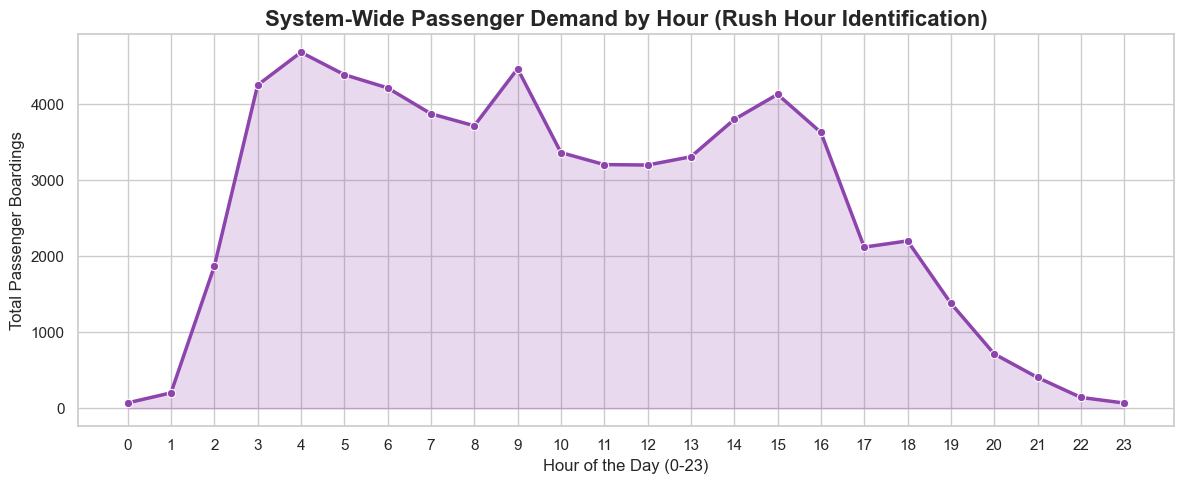

In [ ]:
hourly_demand = df_tickets.groupby('hour').size().reset_index(name='total_boardings')

plt.figure(figsize=(12, 5))
sns.lineplot(data=hourly_demand, x='hour', y='total_boardings', marker='o', color='#8e44ad', linewidth=2.5)
plt.fill_between(hourly_demand['hour'], hourly_demand['total_boardings'], alpha=0.2, color='#8e44ad')
plt.title('Passenger Demand by Hour', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Total Boardings')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

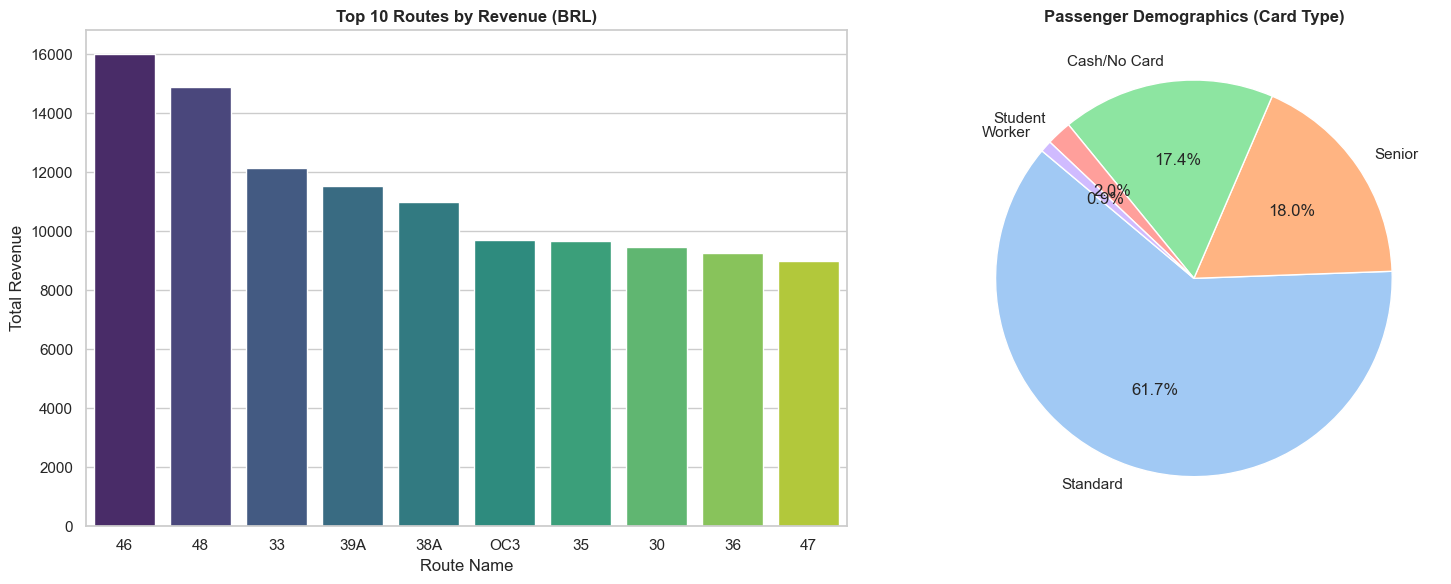

In [ ]:
route_revenue = df_tickets.groupby('route_name')['debited_amount'].sum().reset_index()
top_routes_rev = route_revenue.sort_values('debited_amount', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=top_routes_rev, x='route_name', y='debited_amount', ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Routes by Revenue (BRL)', fontweight='bold')
axes[0].set_ylabel('Total Revenue')
axes[0].set_xlabel('Route')

card_counts = df_tickets['card_label'].value_counts()
axes[1].pie(card_counts, labels=card_counts.index, autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('pastel'))
axes[1].set_title('Passenger Card Type', fontweight='bold')

plt.tight_layout()
plt.show()